# Function 6 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2, x3, x4, x5)` that **minimizes** an
unknown ("black-box") 5D function. A Gaussian Process (GP) surrogate model is fit to the
observed data, and acquisition functions (Expected Improvement, Upper Confidence Bound) are
used to decide which point to query next.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_6/data/initial_inputs.npy")
y = np.load("function_6/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
X = np.append(X, [
    [0.381380, 0.098554, 0.582360, 0.694000, 0.050001],
    [0.453794, 0.184473, 0.988142, 0.998891, 0.050898],
    [0.277827, 0.956981, 0.000001, 0.206641, 0.999999],
    [0.570065, 0.956981, 0.000001, 0.101624, 0.856254],
    [0.586539, 0.999999, 0.000001, 0.331256, 0.999999],
    [0.426242, 0.818011, 0.000001, 0.151686, 0.985804],
    [0.009710, 0.979677, 0.029675, 0.011367, 0.857560],
    [0.991969, 0.051404, 0.070836, 0.075735, 0.870600],
    [0.000099, 0.000099, 0.999999, 0.999999, 0.000099],
    [0.484049, 0.678901, 0.271350, 0.335382, 0.698715],
    [0.484318, 0.679087, 0.270699, 0.334953, 0.698664],
    [0.500839, 0.515540, 0.502550, 0.043551, 0.864080],
    [0.005839, 0.715540, 0.052550, 0.023551, 0.859080],
    ], axis=0)

y = np.append(y, [
    -0.4954099363279621,
    -0.8394620905844289,
    -2.8364473431493304,
    -2.8234388895191542,
    -2.749511962475701,
    -2.6851347336490403,
    -3.1365278755680133,
    -2.9426061795564706,
    -1.371330960346764,
    -1.7887158074731793,
    -1.7863382247048996,
    -1.9252627650606589,
    -2.839914402223155,
    ], axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best (lowest) observed y so far: {min(y)}")

X shape: (33, 5), y shape: (33,)
Best (lowest) observed y so far: -3.1365278755680133


## 3. Gaussian Process Surrogate Model

This is a **minimization** problem, so `current_best` tracks the lowest observed value.

In [4]:
current_best = np.min(y)
kernel = C(1.0) * Matern(length_scale=[0.5] * 5, length_scale_bounds=(0.1, 10), nu=2.5)
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1, n_restarts_optimizer=20)
gp_model.fit(X, y)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified up

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.","1**2 * Matern... 0.5], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.5], nu=2.5)"
,kernel__k1__constant_value,1.0
,kernel__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k2__length_scale,"[0.5, 0.5, ...]"
,kernel__k2__length_scale_bounds,"(0.1, ...)"
,kernel__k2__nu,2.5
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'


In [5]:
optimized_kernel = gp_model.kernel_
length_scales = optimized_kernel.get_params()['k2__length_scale']

print("--- Hyperparameter Check ---")
for i, ls in enumerate(length_scales):
    print(f"Parameter x{i+1} Length Scale: {ls:.4f}")

if np.any(np.isclose(length_scales, 0.01)) or np.any(np.isclose(length_scales, 10.0)):
    print("\nWARNING: One or more length scales are hitting the bounds. Consider widening 'length_scale_bounds'.")

--- Hyperparameter Check ---
Parameter x1 Length Scale: 10.0000
Parameter x2 Length Scale: 10.0000
Parameter x3 Length Scale: 10.0000
Parameter x4 Length Scale: 3.1706
Parameter x5 Length Scale: 2.3188



## 4. Acquisition Functions

### Expected Improvement (EI)
Since this is a minimization problem, improvement is `current_best - mu` (larger is better),
not `mu - current_best` as in the maximization notebooks.

In [6]:
def expected_improvement(x_test, xi=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    if sigma <= 0:
        return 0.0
    imp = current_best - mu - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # negate for minimize

In [7]:
np.random.seed(42)
X_random = np.random.uniform(0, 1, (50000, 5))
ei_scores = [expected_improvement(x) for x in X_random]

x_best_guess = X_random[np.argmin(ei_scores)]
res = minimize(expected_improvement, x_best_guess, bounds=[(0, 1)] * 5, method='L-BFGS-B')

x_best = X[np.argmin(y)]
res_curr = minimize(expected_improvement, x_best, bounds=[(0, 1)] * 5, method='L-BFGS-B')

print(f"Global Best Point (Random Search): {x_best_guess}")
print(f"Refined Peak Point (L-BFGS-B): {res.x}")
print(f"Current Peak Point (L-BFGS-B): {res_curr.x}")

next_point = res.x

Global Best Point (Random Search): [0.97293481 0.00563328 0.98566602 0.98046164 0.99615079]
Refined Peak Point (L-BFGS-B): [0.97293481 0.00563328 0.98566602 0.98046164 0.99615079]
Current Peak Point (L-BFGS-B): [0.00971  0.979677 0.029675 0.011367 0.85756 ]


Third iteration — a major correction to the core logic: an earlier version of this
acquisition function was accidentally maximizing the objective (making the negative less
negative) instead of minimizing it, which produced recommendations that didn't make sense
given all ingredients are required. The sign has been corrected above.

Suggestion for the next iteration: lower the exploration parameter to favor exploitation, and
lower the length scales (e.g. to 0.2–0.8) to keep the model in a sensible range.

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off.

In [8]:
def ucb_loss(x_test, kappa=10):
    mu, sigma = gp_model.predict(x_test.reshape(1, -1), return_std=True)
    ucb = mu + kappa * sigma
    return ucb

x_init = X[np.argmin(y)]  # start from current best
res = minimize(ucb_loss, x_init, bounds=[(0, 1)] * 5, method='L-BFGS-B')

print(f"Current Best Y: {np.min(y)}")
print(f"Next Suggested Point (UCB): {res.x}")

Current Best Y: -3.1365278755680133
Next Suggested Point (UCB): [0.45559508 0.68305745 0.25547726 0.29324489 0.72870226]


### Ranked Observations
A quick sanity check on where the current samples rank by yield.

In [9]:
sorted_indices = np.argsort(y)
sorted_values = y[sorted_indices]

print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 26         | -3.14
1      | 27         | -2.94
2      | 32         | -2.84
3      | 22         | -2.84
4      | 23         | -2.82
5      | 24         | -2.75
6      | 25         | -2.69
7      | 8          | -2.57
8      | 18         | -2.16
9      | 14         | -2.02
10     | 31         | -1.93
11     | 11         | -1.91
12     | 29         | -1.79
13     | 30         | -1.79
14     | 19         | -1.75
15     | 15         | -1.70
16     | 7          | -1.69
17     | 2          | -1.67
18     | 12         | -1.62
19     | 3          | -1.54
20     | 28         | -1.37
21     | 13         | -1.36
22     | 9          | -1.31
23     | 16         | -1.29
24     | 5          | -1.25
25     | 6          | -1.23
26     | 1          | -1.21
27     | 10         | -1.14
28     | 17         | -0.94
29     | 21         | -0.84
30     | 4          | -0.83
31     | 0          | -0.71
32     | 20         | -0.50


## 5. Supplementary Analysis — Neural Network Saliency

Existing samples are manually labeled "positive" (low-yield, listed indices) or "negative",
and a small neural network is trained on that split as a sanity check on whether the
acquisition function's suggested `next_point` also looks promising from a classification
standpoint. This is exploratory and not part of the core GP/acquisition-function decision loop.

In [10]:
y_labels = np.zeros(len(X))
positive_indices = [23, 22, 15, 20, 18, 14, 4, 9, 21, 7, 24, 25]
y_labels[positive_indices] = 1

X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_deep = nn.Sequential(
    nn.Linear(5, 36),
    nn.ReLU(),
    nn.Linear(36, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

In [11]:
X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.1263
 1    | 0.0000
 2    | 0.0224
 3    | 0.1552
 4    | 0.1576
 5    | 0.0000
 6    | 0.0000
 7    | 0.0645
 8    | 0.0028
 9    | 0.2537
10    | 0.0001
11    | 0.0822
12    | 0.0077
13    | 0.0184
14    | 0.3522
15    | 0.0777
16    | 0.0741
17    | 0.0428
18    | 0.0641
19    | 0.0000
20    | 0.1157
21    | 0.0068
22    | 0.1156
23    | 0.0000
24    | 0.0001
25    | 0.0018
26    | 0.1021
27    | 0.0000
28    | 0.0371
29    | 0.2177
30    | 0.2244
31    | 0.1537
32    | 0.0002


In [12]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Next point: {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Next point: [0.97293481 0.00563328 0.98566602 0.98046164 0.99615079]
Probability of being Positive (Class 1): 0.9977
Predicted Class: 1


## 6. Results Summary

Observed yield over the most recent iterations:

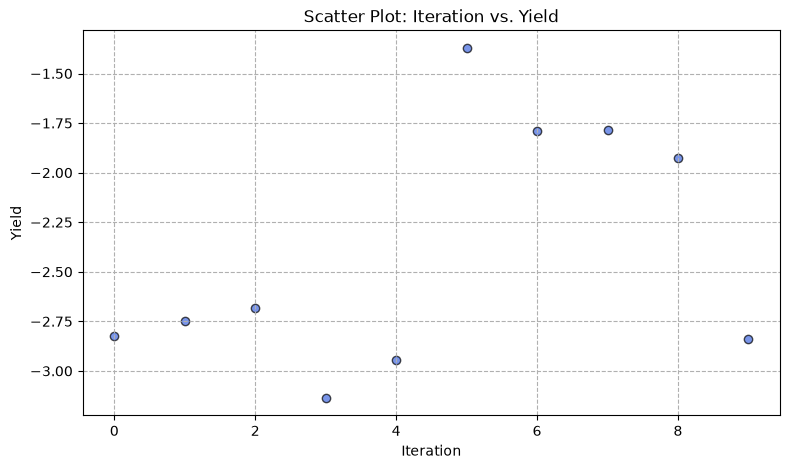

In [13]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=1)
plt.show()